In [1]:
%pip install econml scikit-learn numpy pandas matplotlib

/Users/viegas/Projects/ufv/mestrado/causality-for-data-scientists-course/.venv/bin/python: No module named pip


Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import LogisticRegression
from econml.metalearners import SLearner, TLearner, XLearner
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

# Efeitos Heterogêneos com Meta-Learners

> **Notebook extra.** Esse material não entra na demonstração ao vivo do curso, mas fica aqui pra quem quiser se aprofundar depois.

No Notebook 3 você viu como estimar o **ATE**: um número só, resumindo o efeito causal médio pra toda a população. Só que essa média pode esconder bastante coisa. E se metade das pessoas se beneficia bastante do tratamento, e a outra metade é prejudicada na mesma proporção? A média dá quase zero, só que ninguém na população realmente sente um efeito perto de zero.

É exatamente esse problema que o **CATE** (\textit{Conditional Average Treatment Effect}) resolve: em vez de uma média só, ele estima o efeito condicionado nas características de cada unidade,

$$\tau(x) = \mathbb{E}[Y(1) - Y(0) \mid X = x]$$

Vamos montar um dataset sintético onde essa heterogeneidade acontece de propósito, e comparar três jeitos clássicos de estimar o CATE: **S-learner**, **T-learner** e **X-learner** — os chamados \textit{meta-learners}, porque são construídos em cima de qualquer modelo de ML que você já conhece (aqui, gradient boosting).

## Por que o ATE não é suficiente

Vamos criar uma variável de heterogeneidade $X_{het} \sim \text{Uniform}(0,1)$ que comanda o efeito do tratamento:

$$\tau(x) = 4 \cdot (0.5 - x_{het})$$

Isso dá $+2$ em $x_{het}=0$ (o tratamento **ajuda** bastante) e $-2$ em $x_{het}=1$ (o tratamento **atrapalha** bastante), cruzando o zero em $x_{het}=0.5$. Adicionamos duas covariáveis de ruído, irrelevantes pro resultado, e **confundimos** a alocação do tratamento com o próprio $X_{het}$ — quem tende a se beneficiar mais também tende a ser tratado com mais frequência. Ou seja: isso é um problema de inferência causal de verdade, não uma regressão comum.

$$
\begin{aligned}
X_{het} &\sim \text{Uniform}(0,1) \\
X_{ruido,1}, X_{ruido,2} &\sim \mathcal{N}(0,1) \\
e(x) = P(T=1 \mid x) &= 0.3 + 0.4 \cdot x_{het} \\
T &\sim \text{Bernoulli}(e(x)) \\
Y &= \underbrace{2 + x_{het} + 0.3 \cdot x_{ruido,1}}_{\text{baseline}} \;+\; \tau(x_{het}) \cdot T \;+\; \mathcal{N}(0, 0.5)
\end{aligned}
$$

In [3]:
n = 5000

X_het = np.random.uniform(0, 1, n)
X_noise1 = np.random.normal(0, 1, n)
X_noise2 = np.random.normal(0, 1, n)

X = np.column_stack([X_het, X_noise1, X_noise2])

true_cate = 4 * (0.5 - X_het)                       # +2 ... -2, cruza o zero em x_het=0.5
propensity = 0.3 + 0.4 * X_het
T = np.random.binomial(1, propensity)

baseline = 2 + X_het + 0.3 * X_noise1
noise = np.random.normal(0, 0.5, n)
Y = baseline + true_cate * T + noise

df = pd.DataFrame({
    'X_het': X_het, 'X_noise1': X_noise1, 'X_noise2': X_noise2,
    'T': T, 'Y': Y, 'true_cate': true_cate,
})

print('Formato do dataset:', df.shape)
print(f'P(T=1) = {T.mean():.3f}')
print()
print(f'CATE médio na população (ATE verdadeiro) = {true_cate.mean():+.4f}')
print(f'  Grupo A (x_het < 0.5), CATE médio  = {true_cate[X_het < 0.5].mean():+.4f}  (tratamento AJUDA)')
print(f'  Grupo B (x_het >= 0.5), CATE médio = {true_cate[X_het >= 0.5].mean():+.4f}  (tratamento ATRAPALHA)')

Formato do dataset: (5000, 6)
P(T=1) = 0.489

CATE médio na população (ATE verdadeiro) = +0.0127
  Grupo A (x_het < 0.5), CATE médio  = +1.0183  (tratamento AJUDA)
  Grupo B (x_het >= 0.5), CATE médio = -0.9929  (tratamento ATRAPALHA)


In [ ]:
naive_ate = df[df['T'] == 1].Y.mean() - df[df['T'] == 0].Y.mean()
print(f'Diferença ingênua de médias (confundida): {naive_ate:+.4f}')
print(f'ATE verdadeiro da população (via true_cate): {true_cate.mean():+.4f}')
print()
print('Os dois números ficam perto de zero mas por motivos bem diferentes.')
print('O ATE verdadeiro é perto de zero porque os efeitos de +2 e -2 dos subgrupos se cancelam, e NÃO porque o tratamento não faz nada.')
print('Quem decidisse olhando só pro ATE concluiria "o tratamento não importa" e trataria todo mundo (ou ninguém) sem perceber que quase metade da população se beneficia bastante e a outra metade é ativamente prejudicada.')

Diferença ingênua de médias (confundida): -0.1210
ATE verdadeiro da população (via true_cate): +0.0127

Os dois números ficam perto de zero — mas por motivos bem diferentes. O ATE verdadeiro
é perto de zero porque os efeitos de +2 e -2 dos subgrupos se cancelam, e NÃO porque o
tratamento não faz nada. Quem decidisse olhando só pro ATE concluiria "o tratamento não
importa" e trataria todo mundo (ou ninguém) — sem perceber que quase metade da população
se beneficia bastante e a outra metade é ativamente prejudicada.


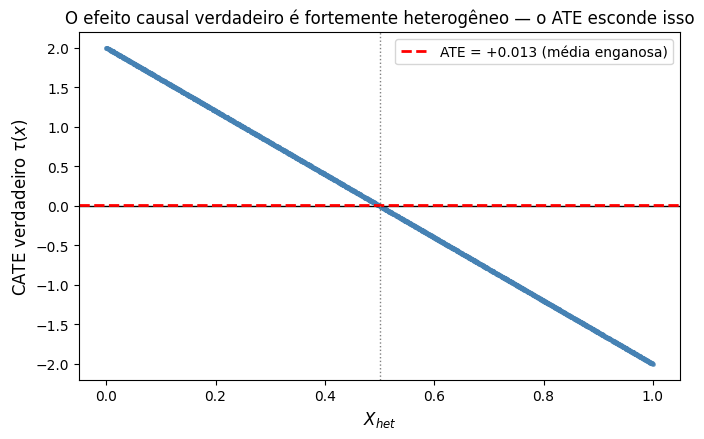

In [5]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(X_het, true_cate, s=6, alpha=0.3, color='steelblue')
ax.axhline(0, color='black', linewidth=1)
ax.axhline(true_cate.mean(), color='red', linestyle='--', linewidth=2,
           label=f'ATE = {true_cate.mean():+.3f} (média enganosa)')
ax.axvline(0.5, color='gray', linestyle=':', linewidth=1)
ax.set_xlabel('$X_{het}$', fontsize=12)
ax.set_ylabel('CATE verdadeiro $\\tau(x)$', fontsize=12)
ax.set_title('O efeito causal verdadeiro é fortemente heterogêneo — o ATE esconde isso', fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('../../figures/5_true_cate.png', dpi=150, bbox_inches='tight')
plt.show()

## S-learner (um modelo só)

O **S-learner** ajusta um único modelo do resultado $\hat\mu(t, x)$, usando o indicador de tratamento como só mais uma variável, e depois calcula:

$$\hat\tau(x) = \hat\mu(1, x) - \hat\mu(0, x)$$

Como $T$ é só mais uma variável entre várias, um modelo flexível (tipo gradient boosting) pode acabar **dando pouco peso** a ela, na comparação com as outras covariáveis — principalmente quando o efeito de $T$ sobre $Y$ é menor, em magnitude, do que a dependência do baseline em $X$. Isso tende a **encolher as estimativas de CATE em direção a zero**.

In [6]:
X_train = df[['X_het', 'X_noise1', 'X_noise2']].values
T_train = df['T'].values
Y_train = df['Y'].values

s_learner = SLearner(overall_model=GradientBoostingRegressor(n_estimators=100, max_depth=3, random_state=0))
s_learner.fit(Y_train, T_train, X=X_train)
cate_s = s_learner.effect(X_train)

bias_s = cate_s - true_cate
print(f'S-learner  — CATE médio estimado: {cate_s.mean():+.4f}  (média verdadeira: {true_cate.mean():+.4f})')
print(f'S-learner  — RMSE vs. CATE verdadeiro: {np.sqrt((bias_s**2).mean()):.4f}')
print(f'S-learner  — viés médio          : {bias_s.mean():+.4f}')
print(f'S-learner  — desvio padrão das estimativas: {cate_s.std():.4f}   (desvio verdadeiro: {true_cate.std():.4f})')

S-learner  — CATE médio estimado: +0.0007  (média verdadeira: +0.0127)
S-learner  — RMSE vs. CATE verdadeiro: 0.2308
S-learner  — viés médio          : -0.0119
S-learner  — desvio padrão das estimativas: 1.0127   (desvio verdadeiro: 1.1584)


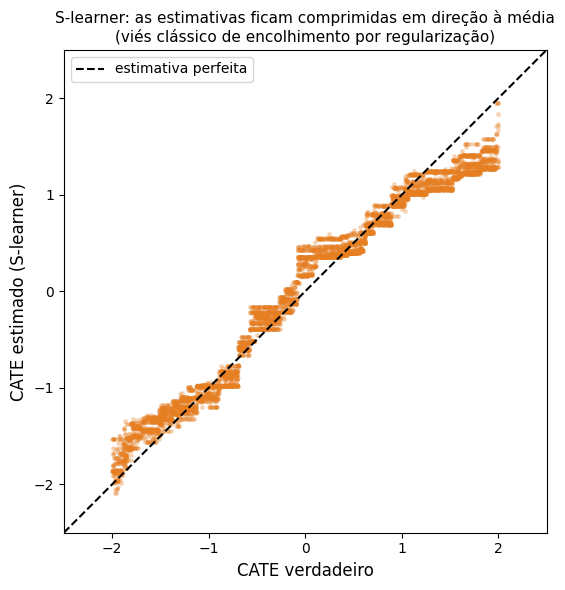

In [7]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(true_cate, cate_s, s=6, alpha=0.25, color='#E67E22')
lims = [-2.5, 2.5]
ax.plot(lims, lims, color='black', linestyle='--', linewidth=1.5, label='estimativa perfeita')
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('CATE verdadeiro', fontsize=12)
ax.set_ylabel('CATE estimado (S-learner)', fontsize=12)
ax.set_title('S-learner: as estimativas ficam comprimidas em direção à média\n(viés clássico de encolhimento por regularização)', fontsize=11)
ax.legend(fontsize=10)
ax.set_aspect('equal')
plt.tight_layout()
plt.savefig('../../figures/5_s_learner.png', dpi=150, bbox_inches='tight')
plt.show()

## T-learner (dois modelos)

O **T-learner** ajusta dois modelos do resultado *separados*, um no subgrupo tratado e outro no subgrupo de controle:

$$\hat\tau(x) = \hat\mu_1(x) - \hat\mu_0(x)$$

Como $T$ deixa de competir com as outras variáveis pela atenção do modelo, o T-learner evita o problema de encolhimento do S-learner. A fraqueza principal dele é o oposto: em regiões com **pouca sobreposição** (poucas unidades tratadas ou poucos controles), cada submodelo precisa extrapolar, o que pode inflar a variância.

In [8]:
t_learner = TLearner(models=GradientBoostingRegressor(n_estimators=100, max_depth=3, random_state=0))
t_learner.fit(Y_train, T_train, X=X_train)
cate_t = t_learner.effect(X_train)

bias_t = cate_t - true_cate
print(f'T-learner  — CATE médio estimado: {cate_t.mean():+.4f}  (média verdadeira: {true_cate.mean():+.4f})')
print(f'T-learner  — RMSE vs. CATE verdadeiro: {np.sqrt((bias_t**2).mean()):.4f}')
print(f'T-learner  — viés médio          : {bias_t.mean():+.4f}')
print(f'T-learner  — desvio padrão das estimativas: {cate_t.std():.4f}   (desvio verdadeiro: {true_cate.std():.4f})')
print()
print(f'O RMSE do S-learner foi {np.sqrt((bias_s**2).mean()):.4f} — o T-learner melhora o problema de encolhimento.')

T-learner  — CATE médio estimado: +0.0193  (média verdadeira: +0.0127)
T-learner  — RMSE vs. CATE verdadeiro: 0.1637
T-learner  — viés médio          : +0.0067
T-learner  — desvio padrão das estimativas: 1.1531   (desvio verdadeiro: 1.1584)

O RMSE do S-learner foi 0.2308 — o T-learner melhora o problema de encolhimento.


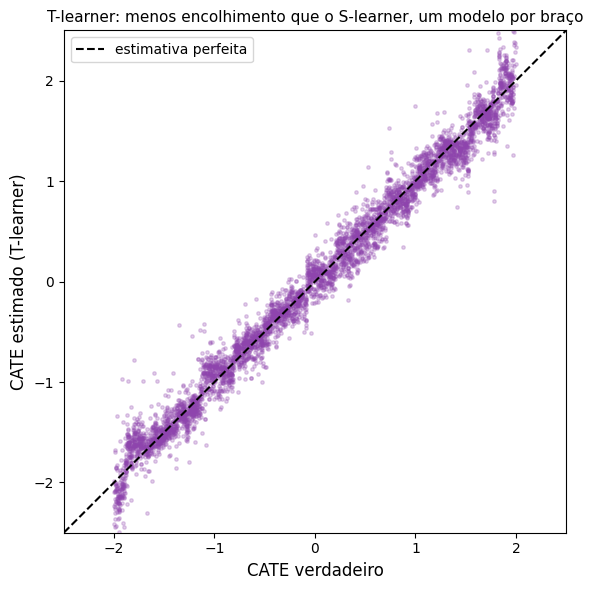

In [9]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(true_cate, cate_t, s=6, alpha=0.25, color='#8E44AD')
ax.plot(lims, lims, color='black', linestyle='--', linewidth=1.5, label='estimativa perfeita')
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('CATE verdadeiro', fontsize=12)
ax.set_ylabel('CATE estimado (T-learner)', fontsize=12)
ax.set_title('T-learner: menos encolhimento que o S-learner, um modelo por braço', fontsize=11)
ax.legend(fontsize=10)
ax.set_aspect('equal')
plt.tight_layout()
plt.savefig('../../figures/5_t_learner.png', dpi=150, bbox_inches='tight')
plt.show()

## X-learner

O **X-learner** é um procedimento em dois estágios, pensado pra situações em que os grupos tratado e controle têm tamanhos bem diferentes (aqui, a probabilidade de tratamento varia de 0.3 a 0.7, então os grupos são moderadamente desbalanceados):

**Estágio 1.** Ajusta $\hat\mu_1$ e $\hat\mu_0$ exatamente como no T-learner.

**Estágio 2.** Imputa um efeito individual pra cada unidade, usando o modelo do *outro* braço pra preencher o contrafactual que falta:

$$
\tilde\tau_i^{(1)} = Y_i - \hat\mu_0(x_i) \quad \text{pras unidades tratadas}, \qquad
\tilde\tau_i^{(0)} = \hat\mu_1(x_i) - Y_i \quad \text{pras unidades de controle}
$$

Ajusta dois modelos de CATE, $\hat\tau_1(x)$ e $\hat\tau_0(x)$, sobre esses efeitos imputados (um por braço), e depois combina os dois usando o score de propensão estimado $\hat e(x)$:

$$\hat\tau(x) = \hat e(x)\,\hat\tau_0(x) + (1-\hat e(x))\,\hat\tau_1(x)$$

Essa ponderação dá mais peso ao modelo treinado no grupo **maior e mais bem representado** em cada $x$ — por exemplo, onde poucas unidades são tratadas, $\hat e(x)$ é pequeno, então $\hat\tau(x)$ se apoia mais em $\hat\tau_1$, ajustado usando as imputações vindas do grupo de controle (relativamente maior).

In [10]:
x_learner = XLearner(
    models=GradientBoostingRegressor(n_estimators=100, max_depth=3, random_state=0),
    propensity_model=LogisticRegression(),
)
x_learner.fit(Y_train, T_train, X=X_train)
cate_x = x_learner.effect(X_train)

bias_x = cate_x - true_cate
print(f'X-learner  — CATE médio estimado: {cate_x.mean():+.4f}  (média verdadeira: {true_cate.mean():+.4f})')
print(f'X-learner  — RMSE vs. CATE verdadeiro: {np.sqrt((bias_x**2).mean()):.4f}')
print(f'X-learner  — viés médio          : {bias_x.mean():+.4f}')
print(f'X-learner  — desvio padrão das estimativas: {cate_x.std():.4f}   (desvio verdadeiro: {true_cate.std():.4f})')
print()
print('Resumo do RMSE:')
print(f'  S-learner : {np.sqrt((bias_s**2).mean()):.4f}')
print(f'  T-learner : {np.sqrt((bias_t**2).mean()):.4f}')
print(f'  X-learner : {np.sqrt((bias_x**2).mean()):.4f}')

X-learner  — CATE médio estimado: +0.0203  (média verdadeira: +0.0127)
X-learner  — RMSE vs. CATE verdadeiro: 0.1215
X-learner  — viés médio          : +0.0077
X-learner  — desvio padrão das estimativas: 1.1491   (desvio verdadeiro: 1.1584)

Resumo do RMSE:
  S-learner : 0.2308
  T-learner : 0.1637
  X-learner : 0.1215


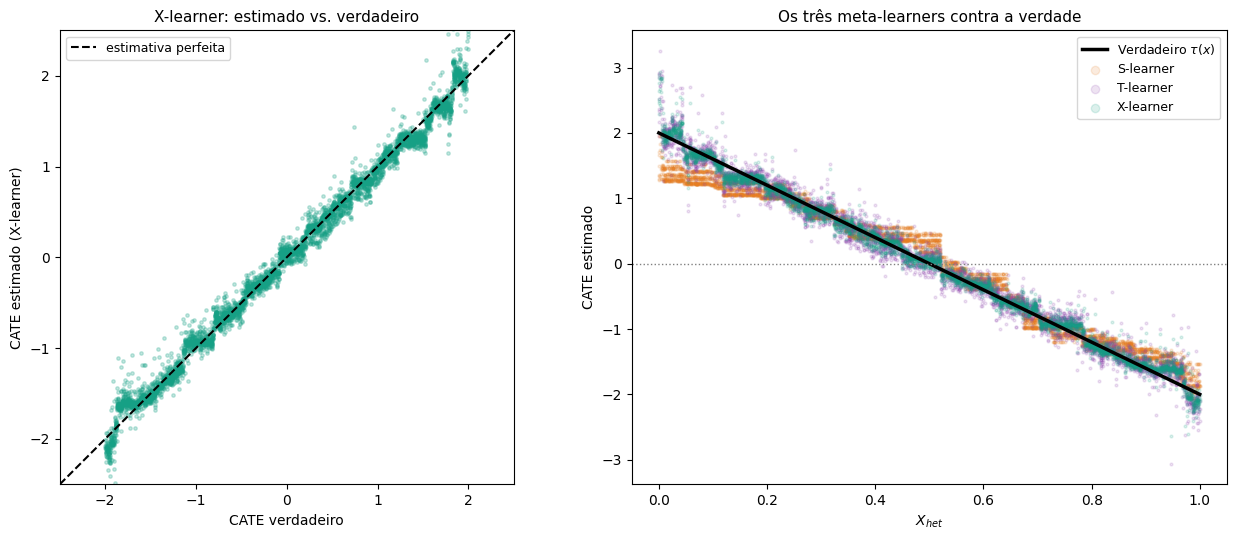

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

axes[0].scatter(true_cate, cate_x, s=6, alpha=0.25, color='#16A085')
axes[0].plot(lims, lims, color='black', linestyle='--', linewidth=1.5, label='estimativa perfeita')
axes[0].set_xlim(lims); axes[0].set_ylim(lims)
axes[0].set_xlabel('CATE verdadeiro'); axes[0].set_ylabel('CATE estimado (X-learner)')
axes[0].set_title('X-learner: estimado vs. verdadeiro', fontsize=11)
axes[0].legend(fontsize=9)
axes[0].set_aspect('equal')

order = np.argsort(X_het)
axes[1].plot(X_het[order], true_cate[order], color='black', linewidth=2.5, label='Verdadeiro $\\tau(x)$')
axes[1].scatter(X_het, cate_s, s=4, alpha=0.15, color='#E67E22', label='S-learner')
axes[1].scatter(X_het, cate_t, s=4, alpha=0.15, color='#8E44AD', label='T-learner')
axes[1].scatter(X_het, cate_x, s=4, alpha=0.15, color='#16A085', label='X-learner')
axes[1].axhline(0, color='gray', linewidth=1, linestyle=':')
axes[1].set_xlabel('$X_{het}$'); axes[1].set_ylabel('CATE estimado')
axes[1].set_title('Os três meta-learners contra a verdade', fontsize=11)
axes[1].legend(fontsize=9, markerscale=3)

plt.tight_layout()
plt.savefig('../../figures/5_all_learners_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Da estimativa à decisão: uma política personalizada

Suponha que precisamos decidir, unidade por unidade, se tratamos ou não. Comparamos três políticas:

- **Tratar todo mundo**: dá o tratamento pra todo mundo.
- **Não tratar ninguém**: não dá o tratamento pra ninguém.
- **Personalizada**: trata a unidade $i$ só se $\hat\tau(x_i) > 0$, usando a estimativa do X-learner.

Como esse é um DGP sintético, dá pra calcular o resultado contrafactual *exato* sob qualquer política, direto da equação estrutural verdadeira — algo impossível com dados reais, mas perfeito pra conferir se a personalização realmente compensa.

In [12]:
def resultado_sob_tratamento(vetor_tratamento):
    # Resultado médio contrafactual exato sob uma dada alocação de tratamento,
    # usando a equação estrutural verdadeira (sem ruído).
    return (baseline + true_cate * vetor_tratamento).mean()

politica_trata_todos = np.ones(n)
politica_nao_trata = np.zeros(n)
politica_personalizada = (cate_x > 0).astype(float)

val_todos = resultado_sob_tratamento(politica_trata_todos)
val_nenhum = resultado_sob_tratamento(politica_nao_trata)
val_personalizada = resultado_sob_tratamento(politica_personalizada)

n_tratados_personalizada = int(politica_personalizada.sum())

tabela_politicas = pd.DataFrame({
    'Política': ['Tratar todos', 'Não tratar ninguém', 'Personalizada (X-learner)'],
    'Fração tratada': [1.0, 0.0, politica_personalizada.mean()],
    'Resultado esperado E[Y]': [val_todos, val_nenhum, val_personalizada],
})
tabela_politicas['Ganho vs. melhor extremo'] = (
    tabela_politicas['Resultado esperado E[Y]'] - max(val_todos, val_nenhum)
)
print(tabela_politicas.to_string(index=False))
print()
print(f'A política personalizada trata {n_tratados_personalizada} / {n} unidades ({politica_personalizada.mean():.1%}).')
print(f'Ela supera a melhor política extrema em {tabela_politicas["Ganho vs. melhor extremo"].iloc[2]:+.4f} no resultado esperado.')

                 Política  Fração tratada  Resultado esperado E[Y]  Ganho vs. melhor extremo
             Tratar todos          1.0000                 2.503974                  0.000000
       Não tratar ninguém          0.0000                 2.491302                 -0.012672
Personalizada (X-learner)          0.5108                 2.999229                  0.495255

A política personalizada trata 2554 / 5000 unidades (51.1%).
Ela supera a melhor política extrema em +0.4953 no resultado esperado.


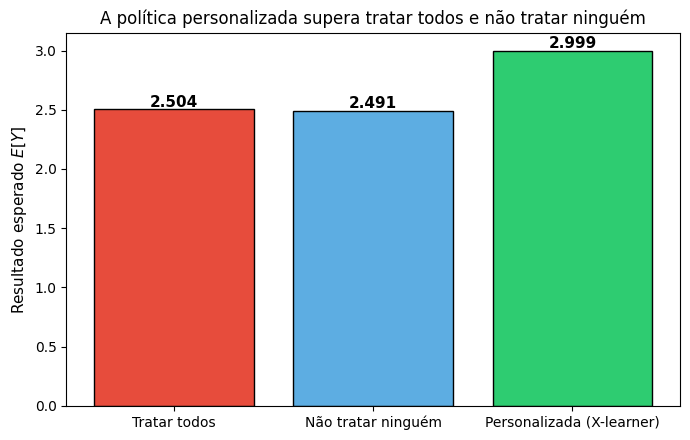

In [13]:
fig, ax = plt.subplots(figsize=(7, 4.5))
colors = ['#E74C3C', '#5DADE2', '#2ECC71']
bars = ax.bar(tabela_politicas['Política'], tabela_politicas['Resultado esperado E[Y]'], color=colors, edgecolor='black')
for bar, v in zip(bars, tabela_politicas['Resultado esperado E[Y]']):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.02, f'{v:.3f}', ha='center', fontsize=11, fontweight='bold')
ax.set_ylabel('Resultado esperado $E[Y]$', fontsize=11)
ax.set_title('A política personalizada supera tratar todos e não tratar ninguém', fontsize=12)
plt.tight_layout()
plt.savefig('../../figures/5_policy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Concluindo...

### 1. O ATE pode ser ativamente enganoso

Quando subgrupos têm efeitos de sinal oposto, o ATE pode ficar perto de zero mesmo que *ninguém* de fato sinta um efeito perto de zero. Confiar só no ATE leva a decisões ruins do tipo "trata todo mundo" ou "não trata ninguém" — algo comum em saúde (um remédio que ajuda um genótipo e prejudica outro) e marketing (uma promoção que ajuda cliente sensível a preço e irrita cliente fiel).

### 2. Os meta-learners trocam viés por variância de formas diferentes

| Learner | Mecanismo | Modo de falha típico |
|---|---|---|
| **S-learner** | Um modelo só, T como variável | Encolhe o CATE em direção a zero quando o efeito de T é pequeno perto das outras variáveis |
| **T-learner** | Dois modelos separados | Mais variância quando a sobreposição entre tratados/controles é ruim |
| **X-learner** | Dois estágios, combinação ponderada por propensão | O melhor dos dois mundos quando os grupos de tratamento são desbalanceados em tamanho |

### 3. O CATE viabiliza personalização

Com uma estimativa de CATE em mãos, a regra de decisão natural "trata se $\hat\tau(x) > 0$" é simples de montar e, como vimos aqui, pode superar qualquer política única pra todo mundo. A qualidade da política personalizada só é tão boa quanto o estimador de CATE por trás dela — e é exatamente por isso que a escolha do meta-learner importa na prática.